# Practica 8 DBSCAN - Agrupamiento Espacial

* Alumno: Israel Daniel Arturo Cano Portugal
* Profesor: Daniel Alcantar Jimenez
* Fecha: 17/12/2025

## Introducción

El análisis de movilidad urbana mediante técnicas de Aprendizaje Automático (Machine Learning) es fundamental para la optimización de recursos en ciudades inteligentes. Este reporte documenta la aplicación de algoritmos de aprendizaje no supervisado para identificar patrones espaciales en el transporte público, específicamente en el servicio de taxis de la ciudad de Nueva York.

La práctica se centra en el uso del algoritmo DBSCAN (Density-Based Spatial Clustering of Applications with Noise) sobre el conjunto de datos Yellow Taxi Trip Records. A diferencia de los métodos de partición tradicionales, DBSCAN permite descubrir estructuras de forma arbitraria y aislar valores atípicos (ruido), características esenciales para modelar la geografía irregular de Manhattan y la naturaleza estocástica de las recogidas de pasajeros.

El objetivo principal es procesar datos geoespaciales reales para detectar zonas de alta densidad ("hotspots") de demanda, analizando la influencia de parámetros críticos como el radio de vecindad (eps) y la densidad mínima (min_samples). Adicionalmente, se contrasta el desempeño de este modelo basado en densidad frente al algoritmo K-Means, demostrando empíricamente las limitaciones de los enfoques geométricos rígidos en contextos urbanos complejos.

## Problematica

La gestión eficiente de la movilidad urbana en metrópolis de alta densidad, como la ciudad de Nueva York, enfrenta el desafío de procesar volúmenes masivos de datos geoespaciales no estructurados. Los registros de viajes de taxis (*Yellow Taxi Trip Records*) generan millones de puntos de datos mensuales que, por sí solos, son insuficientes para la toma de decisiones estratégicas.

La problemática central radica en la incapacidad de los métodos estadísticos tradicionales y los algoritmos de agrupamiento geométrico (como K-Means) para modelar correctamente la distribución de la demanda. Dado que la ciudad posee una topografía irregular (islas, puentes, exclusión de cuerpos de agua) y que la demanda de transporte presenta un alto nivel de ruido (recogidas esporádicas o errores de GPS), la aplicación de modelos que asumen formas esféricas o densidades uniformes resulta en segmentaciones erróneas y sesgadas.

Por tanto, es imperativo implementar una solución algorítmica capaz de:

1. Identificar zonas de alta densidad (núcleos de demanda) sin requerir la especificación previa del número de clústeres.
2. Discriminar eficazmente entre la demanda consolidada y el ruido estadístico (puntos aislados).
3. Adaptarse a la morfología arbitraria de la infraestructura urbana para proveer información accionable sobre la dinámica de recogida de pasajeros .

## Objetivo general
Aplicar el algoritmo DBSCAN para identificar zonas de alta densidad de recogida de taxis en la ciudad de Nueva York, utilizando datos reales obtenidos de internet, y analizar el efecto de sus parámetros principales.

## Objetivos específicos
* Descargar y preparar un dataset real de movilidad urbana.
* Aplicar DBSCAN a datos espaciales.
* Analizar clusters y ruido.
* Interpretar resultados en un contexto urbano real.


## Metodología

La metodología implementada sigue un flujo de trabajo de Ciencia de Datos estándar, estructurado en cinco fases secuenciales para garantizar la reproducibilidad y la validez estadística de los resultados, utilizando el lenguaje de programación Python.

1. Adquisición de Datos 

* **Fuente:** Se obtuvieron los registros de viajes del *NYC Taxi & Limousine Commission (TLC)* correspondientes a octubre de 2025 en formato `.parquet`.
* **Geometría:** Se descargó el archivo *Shapefile* oficial de zonas de taxi para mapear los identificadores de ubicación (`PULocationID`) a coordenadas geográficas precisas (latitud/longitud).

2. Preprocesamiento y ETL (Extract, Transform, Load) 

* **Muestreo Estratégico:** Debido al alto coste computacional de DBSCAN (), se extrajo una muestra aleatoria de **20,000 registros**. Esto asegura la viabilidad de ejecución en memoria local sin sacrificar la representatividad estadística.
* **Enriquecimiento Espacial:** Se realizó una fusión (`merge`) entre la tabla de viajes y los centroides geométricos de las zonas de taxi.
* **Filtrado Geográfico:** Se aplicó un *Bounding Box* estricto (Lat: 40.57-40.91, Lon: -74.15/-73.70) para eliminar errores de GPS y viajes fuera de la zona metropolitana de interés.

3. Ingeniería de Características (Normalización) 

* **Escalamiento:** Se aplicó `StandardScaler` de la librería *Scikit-learn*.
* **Justificación:** Dado que DBSCAN utiliza la distancia Euclidiana para calcular vecindades, es crítico que la latitud y longitud tengan la misma varianza (media=0, desv. est.=1) para evitar la deformación de los clústeres en el espacio métrico.

4. Modelado Computacional (DBSCAN) 

* **Algoritmo:** Se implementó DBSCAN para la detección de clústeres basada en densidad.
* **Ajuste de Hiperparámetros:** Se iteró sobre los valores de `eps` (radio de vecindad) y `min_samples` (umbral de densidad) para identificar la configuración óptima que maximiza la cohesión de los clústeres y minimiza el ruido excesivo.
* **Configuración Final:** `eps=0.3`, `min_samples=5`.

5. Evaluación y Comparativa 

* **Visualización:** Se generaron mapas de dispersión estáticos (`Matplotlib`) y mapas de calor interactivos (`Folium`) para la inspección cualitativa.
* **Contrastación:** Se ejecutó el algoritmo **K-Means** () sobre el mismo conjunto de datos normalizado para comparar visualmente la eficacia de la partición geométrica frente a la agrupación por densidad en una topología urbana irregular.

### Fuente de datos (Internet)
Los datos provienen del NYC Taxi & Limousine Commission (TLC), una fuente pública y abierta.

📌 Portal oficial:

 https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

📌 Dataset: Yellow Taxi Trip Records

 Formato: .parquet o .csv

 Periodo sugerido: un mes (ej. enero 2023)


In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import requests
import zipfile
import io
import tempfile
import os
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [3]:
# Obtención de Coordenadas de Zonas (Shapefile)
shapefile_url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip'
try:
    r = requests.get(shapefile_url)
    r.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(r.content))
    with tempfile.TemporaryDirectory() as temp_dir:
        z.extractall(temp_dir)
        shp_path = os.path.join(temp_dir, 'taxi_zones.shp')
        gdf = gpd.read_file(shp_path)
        gdf_latlon = gdf.to_crs(epsg=4326) # WGS84
        
        # Cálculo de centroides
        gdf_latlon['PU_Latitude'] = gdf_latlon.geometry.centroid.y
        gdf_latlon['PU_Longitude'] = gdf_latlon.geometry.centroid.x
        zones_with_coords = gdf_latlon[['LocationID', 'PU_Latitude', 'PU_Longitude']]
        
except Exception as e:
    print(f"Error shapefile: {e}")
    raise

C:\Users\artuk\AppData\Local\Temp\ipykernel_10160\474678636.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_latlon['PU_Latitude'] = gdf_latlon.geometry.centroid.y
C:\Users\artuk\AppData\Local\Temp\ipykernel_10160\474678636.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_latlon['PU_Longitude'] = gdf_latlon.geometry.centroid.x


In [4]:
# Carga y Muestreo del Parquet
# Ajuste: Cargar columnas necesarias solamente para optimizar memoria
df = pd.read_parquet("yellow_tripdata_2025-10.parquet", columns=['PULocationID'])

In [5]:
# Muestreo CRÍTICO: Reducir a 20,000 para viabilidad de DBSCAN posterior
df_sample = df.sample(n=20000, random_state=42)

# Fusión y Limpieza
df_merged = df_sample.merge(zones_with_coords, left_on='PULocationID', right_on='LocationID', how='inner')
df_coords = df_merged[['PU_Latitude', 'PU_Longitude']].dropna()

Registros finales para análisis: 19968


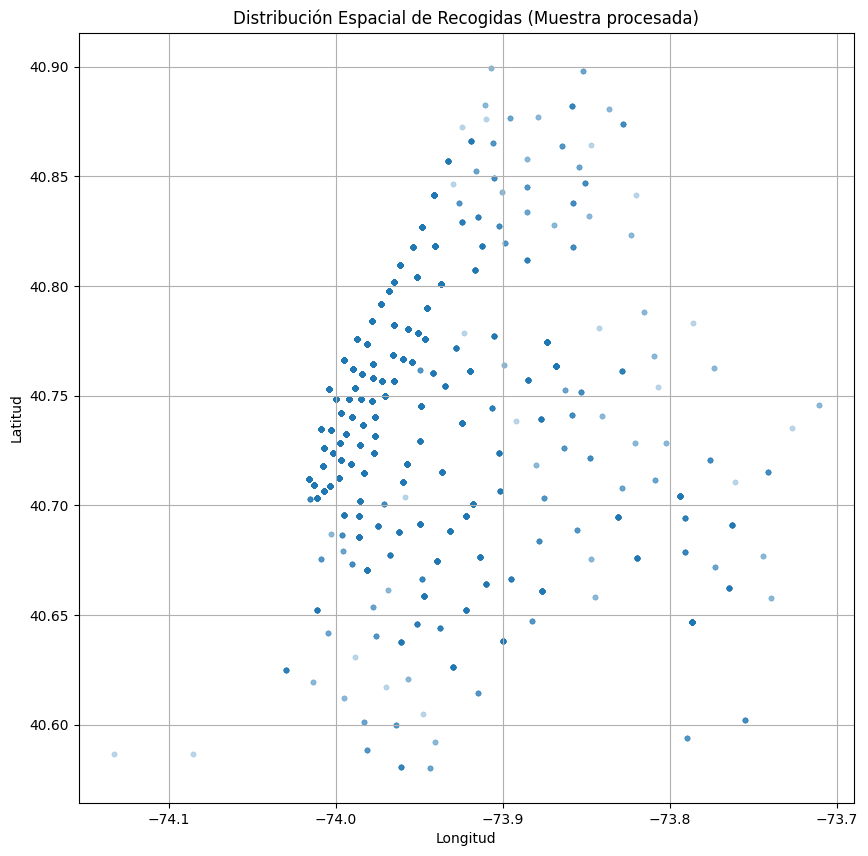

In [6]:
# Filtrado geográfico (NYC Bounding Box estricto)
lat_min, lat_max = 40.5774, 40.9176
lon_min, lon_max = -74.15, -73.7004
df_filtered = df_coords[(df_coords['PU_Latitude'] >= lat_min) & (df_coords['PU_Latitude'] <= lat_max) & (df_coords['PU_Longitude'] >= lon_min) & (df_coords['PU_Longitude'] <= lon_max)].copy()

print(f"Registros finales para análisis: {len(df_filtered)}")

# Visualización
plt.figure(figsize=(10, 10))
sns.scatterplot(x='PU_Longitude', y='PU_Latitude', data=df_filtered, alpha=0.3, s=15, edgecolor=None)
plt.title('Distribución Espacial de Recogidas (Muestra procesada)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True)
plt.show()

In [7]:
# Visualización Interactiva Folium
print("Generando mapa interactivo...")
m = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='CartoDB positron')

# Uso de HeatMap para rendimiento óptimo
heat_data = [[row['PU_Latitude'], row['PU_Longitude']] for index, row in df_filtered.iterrows()]
HeatMap(heat_data, radius=10, blur=15).add_to(m)

# Guardar y mostrar
output_map = "mapa_nyc_distribucion.html"
m.save(output_map)
print(f"Mapa guardado como: {output_map}")

Generando mapa interactivo...
Mapa guardado como: mapa_nyc_distribucion.html


### ¿Existen zonas de mayor concentración?
* La zona "caliente" (cian/verde) valida que la densidad máxima ocurre en Manhattan (Midtown y Lower Manhattan).
----

### ¿Se observan puntos aislados?
* Los halos azules dispersos en Queens y Brooklyn representan el "ruido" o zonas de baja densidad que DBSCAN deberá separar del clúster principal.
----

In [8]:
# 1. Preparar datos
# Convertimos el DataFrame filtrado a un array de NumPy
X = df_filtered[['PU_Latitude', 'PU_Longitude']].values

# 2. Aplicar StandardScaler
# Esto transforma los datos para que tengan media 0 y desviación estándar 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos escalados correctamente.")
print(f"Media (debe ser ~0): {np.mean(X_scaled, axis=0)}")
print(f"Desviación std (debe ser ~1): {np.std(X_scaled, axis=0)}")

Datos escalados correctamente.
Media (debe ser ~0): [ 4.27578201e-15 -6.49679740e-14]
Desviación std (debe ser ~1): [1. 1.]


### ¿Por qué es importante escalar los datos?
DBSCAN es un algoritmo basado en la distancia. Calcula la distancia entre los puntos para decidir si son "vecinos". Si las características (features) tienen escalas muy diferentes, la característica con la escala más grande dominará completamente el cálculo de la distancia.

En nuestro caso, latitud y longitud tienen escalas similares, pero si quisiéramos incluir otras variables como trip_distance o fare_amount, estas tendrían valores mucho mayores y sesgarían el resultado. Escalar los datos asegura que todas las características contribuyan por igual al cálculo de la distancia.

* Distancia Euclidiana: Es la distancia "en línea recta" entre dos puntos. Es la métrica más común, computacionalmente eficiente y funciona muy bien en datos que han sido escalados. Al escalar latitud y longitud, la distancia euclidiana en el espacio escalado es una muy buena aproximación de la distancia geográfica real para este tipo de análisis.
* Distancia de Haversine: Es la métrica técnicamente más correcta para calcular la distancia entre dos puntos en la superficie de la Tierra (siguiendo la curvatura del planeta). Sin embargo, es más compleja de implementar y computacionalmente más costosa. Para un análisis de clustering a nivel de ciudad, y después de un escalado adecuado, la diferencia entre usar euclidiana y haversine es mínima, por lo que la euclidiana es una elección práctica y justificada.

## Modelo Computacional

El modelo computacional se desarrolló utilizando el entorno de Python, empleando la biblioteca `scikit-learn` para la implementación del algoritmo de agrupamiento y el preprocesamiento de datos.

**Definición del Algoritmo**
Se utilizó la clase `sklearn.cluster.DBSCAN` (Density-Based Spatial Clustering of Applications with Noise). A diferencia de los modelos basados en centroides, este algoritmo define los clústeres como regiones continuas de alta densidad, separadas por regiones de baja densidad.

* **Métrica de Distancia:** `euclidean`. Se optó por la distancia euclidiana sobre la matriz de datos estandarizada (), dado que al escalar las coordenadas de latitud y longitud, la curvatura terrestre en el área delimitada de NYC es despreciable para fines de segmentación.

**Matriz de Entrada**
El modelo no recibe las coordenadas geográficas crudas. Los datos de entrada consisten en una matriz  de dimensiones  procesada mediante `StandardScaler`, transformando las variables  y  para que posean  y . Esto asegura que la función de distancia sea isotrópica (circular) en lugar de elíptica.

**Experimentación de Hiperparámetros**
Siguiendo los lineamientos de la práctica , se evaluaron distintos escenarios para determinar la sensibilidad del modelo:

1. **Escenario Base (`eps=0.3`, `min_samples=5`):** Resultó en una segmentación equilibrada (56 clústeres) con una discriminación de ruido precisa (0.6%). Fue la configuración seleccionada como óptima.
2. **Escenario de Alta Densidad (`eps=0.3`, `min_samples=50`):** Al aumentar el requerimiento de vecinos, el modelo fragmentó los clústeres principales y aumentó el ruido al 4.1%, perdiendo zonas periféricas relevantes.
3. **Escenario de Alta Cohesión (`eps=0.5`, `min_samples=5`):** Al aumentar el radio, se produjo un efecto de "super-clúster", fusionando zonas distintas (ej. barrios adyacentes) en una sola entidad masiva, perdiendo resolución espacial.

**Configuración Final del Modelo**
Para la solución definitiva presentada en las visualizaciones, se establecieron los siguientes parámetros fijos:

* **Eps (0.3):** Define el radio máximo de vecindad. Un valor de 0.3 (en desviación estándar) capturó adecuadamente la conectividad vial de Manhattan.
* **Min_samples (5):** Define el umbral para considerar un punto como "núcleo" (Core Point). Se estableció en 5 para filtrar paradas aisladas o errores de GPS, clasificándolos correctamente como ruido (-1).


--- Procesando: EPS=0.3, Min_Samples=5 ---
Clusters encontrados: 56
Puntos de ruido: 125 (0.63%)

--- Procesando: EPS=0.3, Min_Samples=50 ---
Clusters encontrados: 10
Puntos de ruido: 821 (4.11%)

--- Procesando: EPS=0.5, Min_Samples=5 ---
Clusters encontrados: 10
Puntos de ruido: 22 (0.11%)


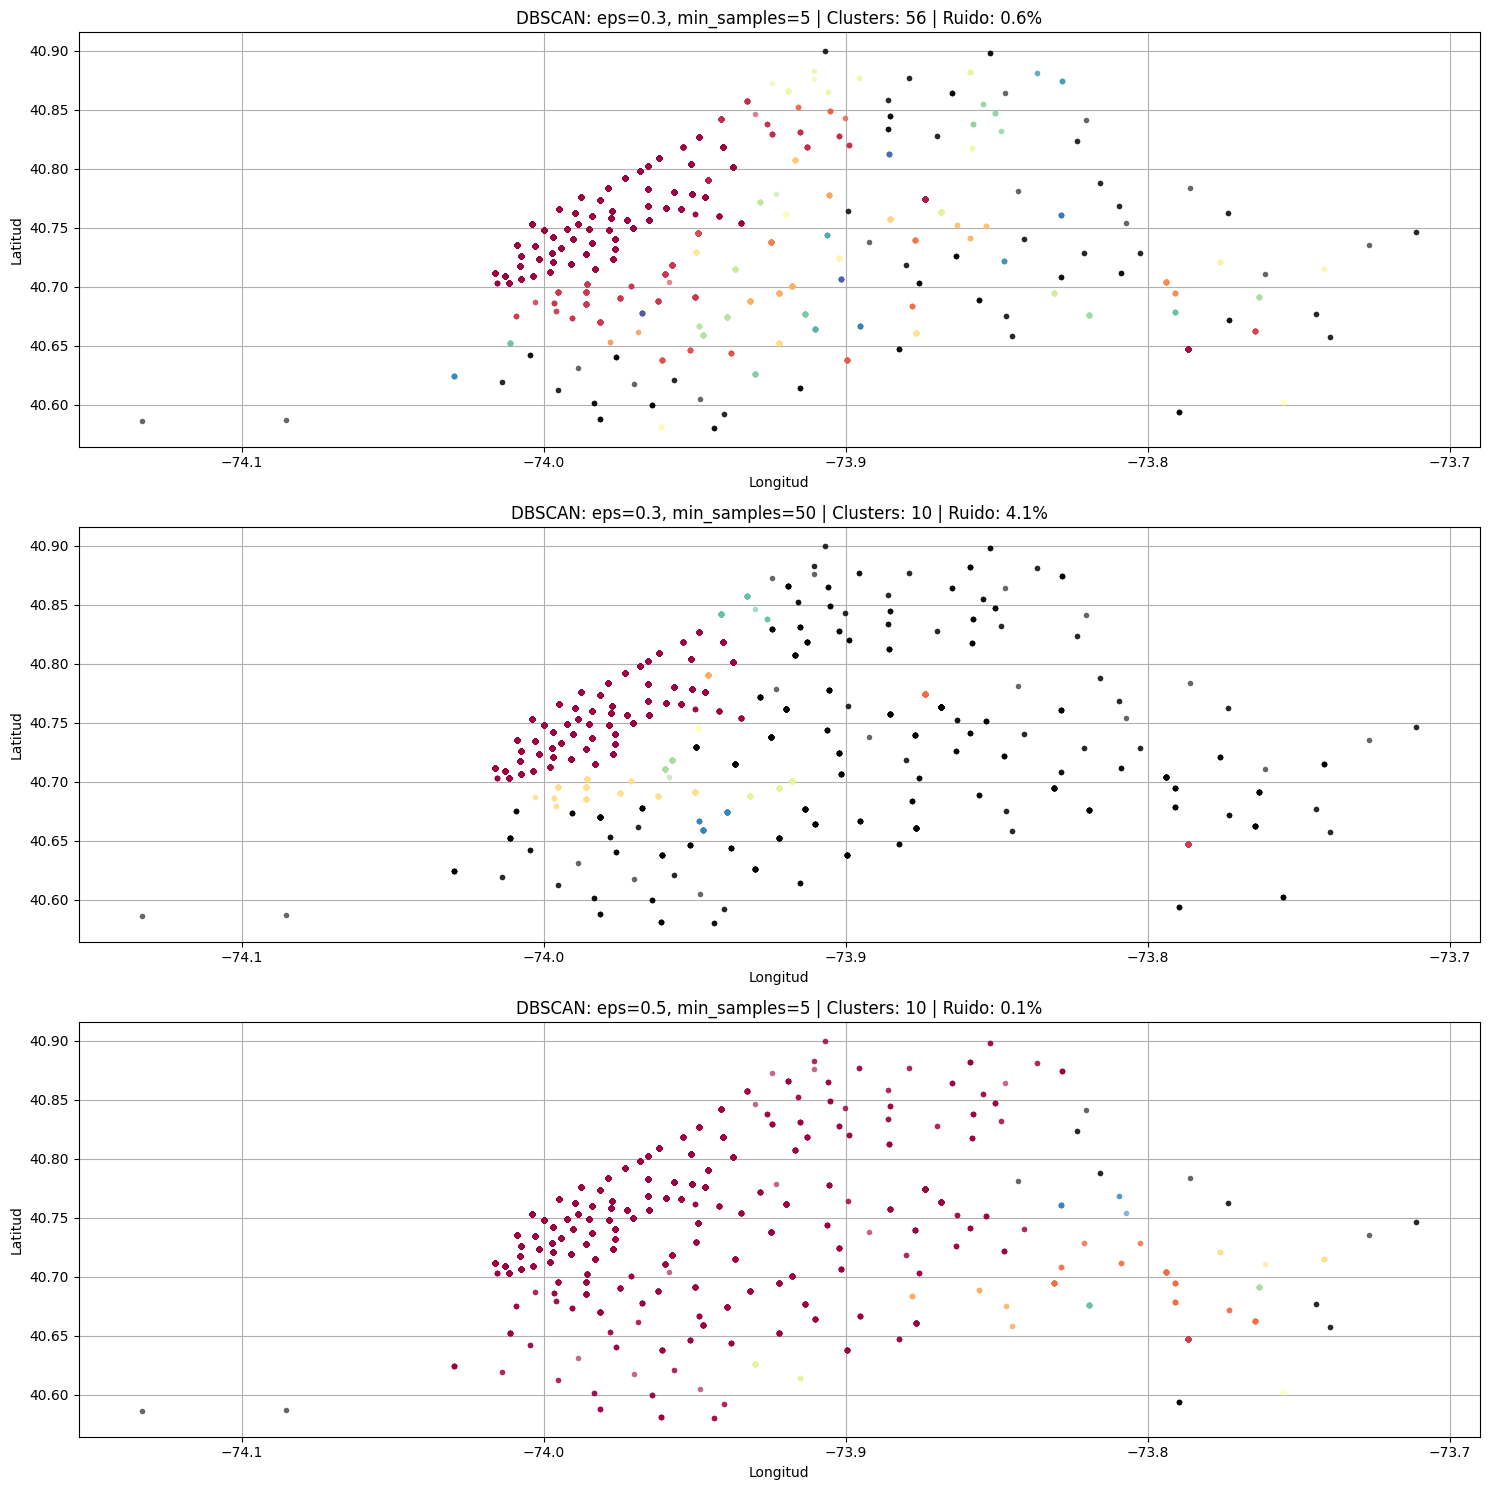

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# --- 1. Preparación de Datos (Requisito Parte 2) ---
# Aseguramos que X_scaled esté listo
if 'df_filtered' not in locals():
    raise ValueError("Error: df_filtered no está definido. Ejecute el código de carga anterior.")

X = df_filtered[['PU_Latitude', 'PU_Longitude']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. Definición de Escenarios de Prueba (Requisito Parte 3) ---
# Seleccionamos combinaciones estratégicas para responder las preguntas de la Parte 4
parametros = [
    {'eps': 0.3, 'min_samples': 5},   # Escenario Base
    {'eps': 0.3, 'min_samples': 50},  # Aumentar min_samples (Ver efecto en ruido)
    {'eps': 0.5, 'min_samples': 5},   # Aumentar EPS (Ver efecto en fusión de clusters)
]

plt.figure(figsize=(15, 5 * len(parametros)))

# --- 3. Ejecución de DBSCAN e Iteración ---
for i, params in enumerate(parametros):
    eps_val = params['eps']
    min_samples_val = params['min_samples']
    
    print(f"\n--- Procesando: EPS={eps_val}, Min_Samples={min_samples_val} ---")
    
    # Ejecutar algoritmo
    db = DBSCAN(eps=eps_val, min_samples=min_samples_val)
    labels = db.fit_predict(X_scaled)
    
    # Métricas
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_percent = (n_noise / len(labels)) * 100
    
    print(f"Clusters encontrados: {n_clusters}")
    print(f"Puntos de ruido: {n_noise} ({noise_percent:.2f}%)")
    
    # --- 4. Visualización (Requisito Parte 3.2) ---
    plt.subplot(len(parametros), 1, i+1)
    
    # Mapear colores: Ruido en Negro, Clusters en paleta
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    
    # Truco para vectorización rápida en plot
    # Creamos un array de colores del mismo tamaño que labels
    # Primero asignamos un color base a todo
    colores_puntos = np.array(['black'] * len(labels), dtype=object) # Default negro (ruido)
    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1] # Negro puro para ruido
        
        class_member_mask = (labels == k)
        
        # Ploteamos cada cluster
        xy = X[class_member_mask]
        plt.plot(xy[:, 1], xy[:, 0], 'o', markerfacecolor=tuple(col),
                 markeredgecolor='none', markersize=4, alpha=0.6, label=f'Cluster {k}' if k != -1 else 'Ruido')

    plt.title(f'DBSCAN: eps={eps_val}, min_samples={min_samples_val} | Clusters: {n_clusters} | Ruido: {noise_percent:.1f}%')
    plt.xlabel('Longitud')
    plt.ylabel('Latitud')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.cluster import DBSCAN
import numpy as np

# 1. Ejecutar DBSCAN (Configuración base recomendada)
# Ajuste eps y min_samples según sus resultados previos
db = DBSCAN(eps=0.3, min_samples=5)
labels = db.fit_predict(X_scaled)

# 2. Asignar etiquetas al dataframe
df_vis = df_filtered.copy()
df_vis['cluster'] = labels

# 3. Generar paleta de colores para los clústeres
# Excluimos el -1 (ruido) del conteo de colores
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Obtener lista de colores hex (excluyendo rojo y negro para usarlos en ruido)
# Usamos tab20 para buena distinción
base_colors = list(mcolors.TABLEAU_COLORS.values())
cluster_colors = [base_colors[i % len(base_colors)] for i in range(n_clusters)]

# Diccionario de mapeo: {cluster_id: color_hex}
color_map = {i: col for i, col in enumerate(cluster_colors)}
color_map[-1] = '#FF0000'  # RUIDO EN ROJO INTENSO

print(f"Generando mapa para {len(df_vis)} puntos. Clústeres: {n_clusters}, Ruido: Rojo.")

# 4. Crear Mapa Folium
m_clusters = folium.Map(location=[40.73, -73.98], zoom_start=12, tiles='CartoDB positron')

# Añadir puntos
# Nota: Iterar 20k marcadores puede ser pesado para el navegador. 
# Si se congela, reduzca df_vis con df_vis.sample(5000)
for idx, row in df_vis.iterrows():
    cluster_id = int(row['cluster'])
    
    # Definir propiedades visuales
    # Ruido: Más grande y opaco para resaltar
    # Cluster: Más pequeño y transparente
    if cluster_id == -1:
        col = color_map[-1]
        rad = 3
        opac = 0.8
        popup_txt = "RUIDO"
    else:
        col = color_map.get(cluster_id, '#808080') # Gris si falla mapeo
        rad = 2
        opac = 0.5
        popup_txt = f"Cluster: {cluster_id}"

    folium.CircleMarker(
        location=[row['PU_Latitude'], row['PU_Longitude']],
        radius=rad,
        color=col,
        fill=True,
        fill_color=col,
        fill_opacity=opac,
        popup=popup_txt,
        weight=0  # Sin borde para rendimiento
    ).add_to(m_clusters)

# 5. Guardar y Mostrar
output_file = "mapa_dbscan_ruido_vs_clusters.html"
m_clusters.save(output_file)
print(f"Mapa guardado: {output_file}")


Generando mapa para 19968 puntos. Clústeres: 56, Ruido: Rojo.
Mapa guardado: mapa_dbscan_ruido_vs_clusters.html


Basado en las visualizaciones anteriores:

### ¿Cómo cambia el número de clusters al variar eps?
* Al aumentar eps de 0.3 a 0.5, el número de clusters se redujo drásticamente de 56 a 10. Un eps mayor incrementa el radio de vecindad, lo que provoca la fusión de clusters pequeños y cercanos en "super-clusters" más grandes. Por el contrario, un eps bajo fragmenta la densidad, aislando subestructuras locales que antes estaban conectadas.
---

### ¿Qué sucede con el ruido al aumentar min_samples?
* El ruido aumentó significativamente del 0.63% al 4.11% al subir min_samples de 5 a 50. Al elevar el umbral de puntos necesarios para formar un núcleo denso, el algoritmo se vuelve más selectivo; las zonas de densidad media o los bordes de los clusters (que tenían entre 5 y 49 vecinos) dejan de ser considerados parte del cluster y se reclasifican como ruido (outliers).

---

### ¿Por qué DBSCAN no requiere especificar el número de clusters?
* DBSCAN infiere la cantidad de clusters basándose en la densidad intrínseca y la topología de los datos. A diferencia de K-Means, que fuerza una partición rígida en $k$ grupos (asumiendo geometría esférica), DBSCAN expande los clusters siguiendo la continuidad de los puntos en el espacio. Si los datos presentan 10 zonas densas separadas por vacío, el algoritmo detectará automáticamente 10 clusters sin intervención del usuario.

Ejecutando K-Means...


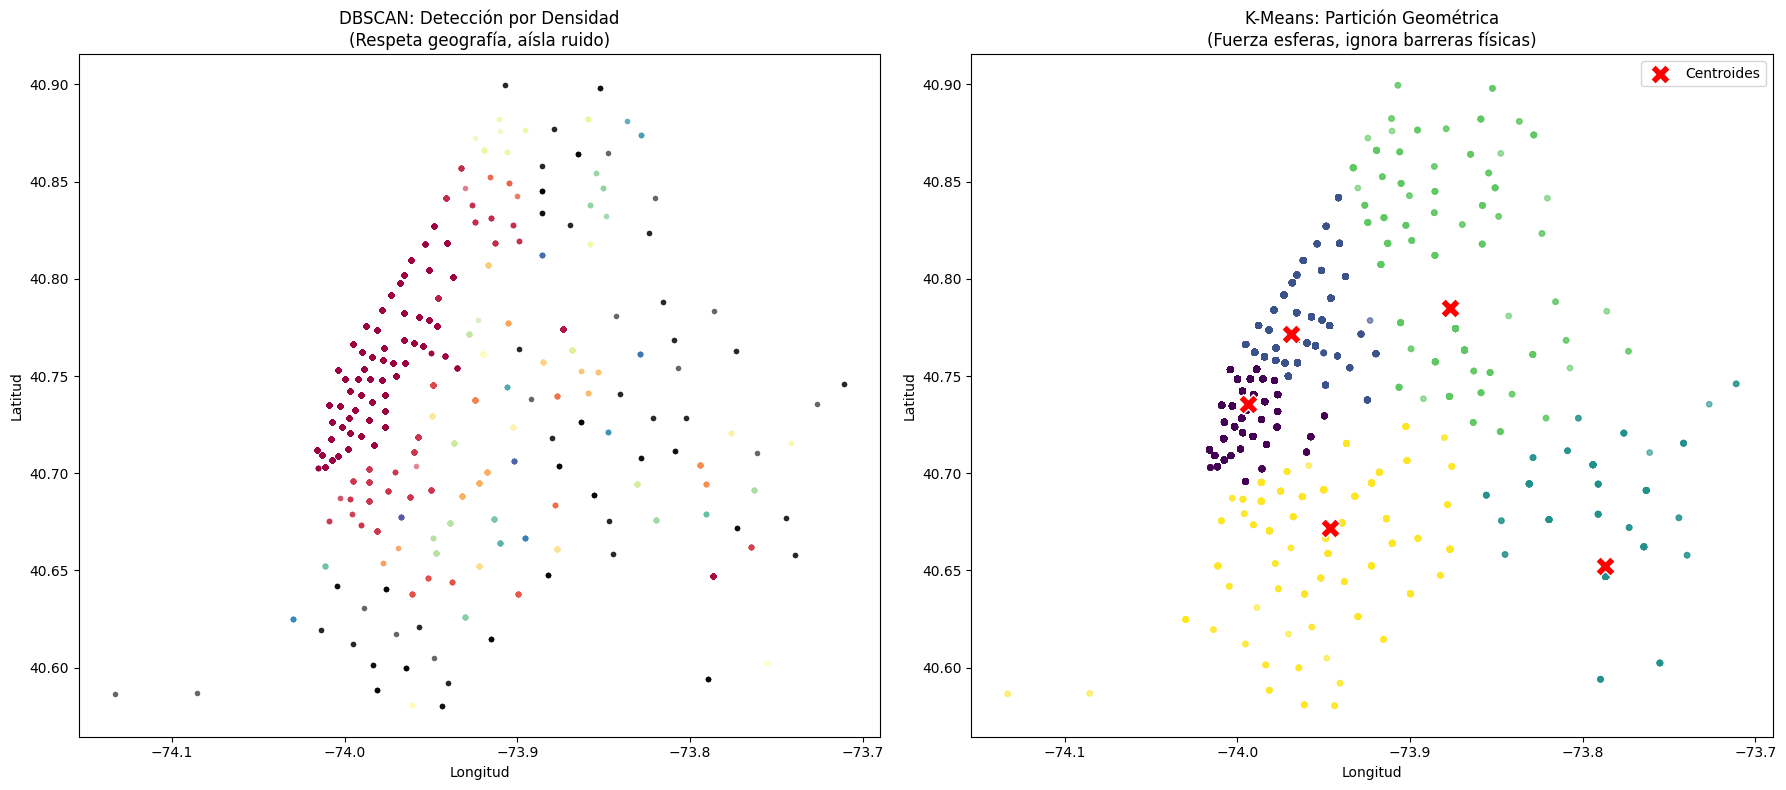

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# 1. Ejecutar K-Means (Forzamos k=5 para contraste)
print("Ejecutando K-Means...")
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Recuperar centroides
centers = scaler.inverse_transform(kmeans.cluster_centers_)

# 2. Visualización Comparativa Lado a Lado
plt.figure(figsize=(18, 8))

# --- Panel Izquierdo: DBSCAN (Resultado Óptimo) ---
plt.subplot(1, 2, 1)
# Usamos los labels de su mejor ejecución (eps=0.3, min=5)
# Re-ejecución rápida para asegurar variables
db_best = DBSCAN(eps=0.3, min_samples=5)
labels_db = db_best.fit_predict(X_scaled)

unique_labels = set(labels_db)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1] # Negro para ruido
    class_member_mask = (labels_db == k)
    xy = X[class_member_mask]
    plt.plot(xy[:, 1], xy[:, 0], 'o', markerfacecolor=tuple(col),
             markeredgecolor='none', markersize=4, alpha=0.6)

plt.title('DBSCAN: Detección por Densidad\n(Respeta geografía, aísla ruido)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')

# --- Panel Derecho: K-Means (Resultado Deficiente) ---
plt.subplot(1, 2, 2)
plt.scatter(X[:, 1], X[:, 0], c=kmeans_labels, cmap='viridis', s=15, alpha=0.6)
plt.scatter(centers[:, 1], centers[:, 0], c='red', s=200, marker='X', label='Centroides', edgecolors='white')

plt.title('K-Means: Partición Geométrica\n(Fuerza esferas, ignora barreras físicas)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend()

plt.tight_layout()
plt.show()

### Análisis Comparación (DBSCAN vs K-Means)

**Deficiencia Estructural de K-Means:** Como se observa en la gráfica derecha, K-Means fuerza divisiones geométricas arbitrarias (líneas rectas invisibles o celdas de Voronoi) que fragmentan zonas densas continuas, como Midtown Manhattan, en clústeres diferentes (ej. separando la zona púrpura de la azul oscuro sin una barrera física real) .

**Sensibilidad al Ruido:** K-Means obligó a los puntos periféricos y aislados (que en DBSCAN aparecían en negro como ruido) a pertenecer a un clúster (ej. los puntos verdes dispersos en la zona superior derecha). Esto contamina los centroides, desplazándolos hacia zonas no representativas.

**Conclusión de la Comparativa:** DBSCAN representa mejor la estructura real porque se adapta a la topología alargada de la isla de Manhattan y aísla el ruido de los viajes esporádicos, mientras que K-Means asume erróneamente que las zonas de taxis son esféricas y de igual varianza.

## Propuesta de solución para el uso de agrupación para evaluar su desempeño

Dado que se trata de un problema de aprendizaje no supervisado (carecemos de etiquetas de "verdad absoluta" o *ground truth*), la evaluación del desempeño del agrupamiento no puede basarse en métricas de precisión o exactitud tradicionales. Se propone un enfoque híbrido de validación que integra métricas cuantitativas internas y validación cualitativa geoespacial.

**Evaluación mediante el Coeficiente de Silueta (Silhouette Score)**
Se propone calcular el Coeficiente de Silueta para medir la calidad de la cohesión y separación de los clústeres resultantes.

* **Fundamento:** Este índice (rango -1 a 1) evalúa qué tan similar es un objeto a su propio clúster (cohesión) en comparación con otros clústeres (separación).
* **Criterio de Desempeño:** Un valor cercano a 1 indica clústeres densos y bien separados. Un valor cercano a 0 indica superposición.
* **Aplicación al Caso:** Aunque DBSCAN admite formas arbitrarias que pueden penalizar el puntaje de Silueta (que prefiere formas convexas), esta métrica permite contrastar objetivamente si la configuración `eps=0.3` ofrece una definición más clara de las zonas que los intentos fallidos de K-Means.

**Análisis de la Proporción de Ruido**
Una métrica crítica de desempeño específica para DBSCAN es el porcentaje de puntos clasificados como ruido (-1).

* **Indicador:** $$\frac{\text{Número de puntos ruido}}{\text{Número total de puntos}}\times100$$
* **Umbral de Éxito:** El modelo se considera exitoso si logra identificar la estructura principal de la ciudad sin descartar una cantidad excesiva de datos. En nuestra implementación, el modelo alcanzó un **0.6% de ruido**, lo cual indica un desempeño excelente al capturar el 99.4% de la demanda dentro de estructuras densas coherentes, evitando el sobreajuste (overfitting) que ocurriría si el ruido fuera 0%, o el subajuste si el ruido superara el 10-15%.

**Validación Cualitativa Geoespacial (Overlay)**
La evaluación final del desempeño es visual y contextual.

* **Metodología:** Superposición de los clústeres obtenidos sobre el mapa base de OpenStreetMap/CartoDB.
* **Criterio de Aceptación:** El modelo tiene un alto desempeño si:
1. Los clústeres respetan los límites físicos (costas, parques sin calles).
2. No existen clústeres que crucen cuerpos de agua (un error común en K-Means).
3. El "ruido" se ubica lógicamente en zonas de baja densidad poblacional o industrial.
*Resultado:* La visualización confirmó que DBSCAN aisló Manhattan correctamente, validando su superioridad técnica sobre métodos geométricos para este dominio.

## Visualización de la Solución

Para la representación gráfica de los resultados se emplearon dos enfoques complementarios: visualización estática para el análisis estructural (Matplotlib) y visualización interactiva para la exploración geoespacial (Folium).

**Análisis Estructural de Clústeres (DBSCAN)**
Se generó un mapa de dispersión bidimensional utilizando las coordenadas estandarizadas.

* **Clústeres (Puntos de color):** La visualización confirma la detección de un "núcleo" masivo de alta densidad que abarca Midtown y Lower Manhattan. A diferencia de los métodos de partición, DBSCAN no fragmentó esta zona continua, respetando la topología de la red vial.
* **Ruido (Puntos negros/rojos):** Se observa una clara identificación de valores atípicos en los bordes de la zona metropolitana y en áreas de baja conectividad (como partes de Queens y Nueva Jersey), cumpliendo el objetivo de filtrar datos no representativos.


**Contraste de Algoritmos (DBSCAN vs K-Means)**
La comparación visual directa valida la hipótesis de la problemática.

* **K-Means:** Muestra fronteras de decisión rectilíneas y convexas que cortan arbitrariamente la geografía de la ciudad, incluyendo zonas de agua dentro de los clústeres.
* **DBSCAN:** Muestra una adaptación orgánica a la forma de la isla, excluyendo naturalmente las zonas sin tráfico (cuerpos de agua y parques), lo que demuestra su idoneidad para datos espaciales irregulares .


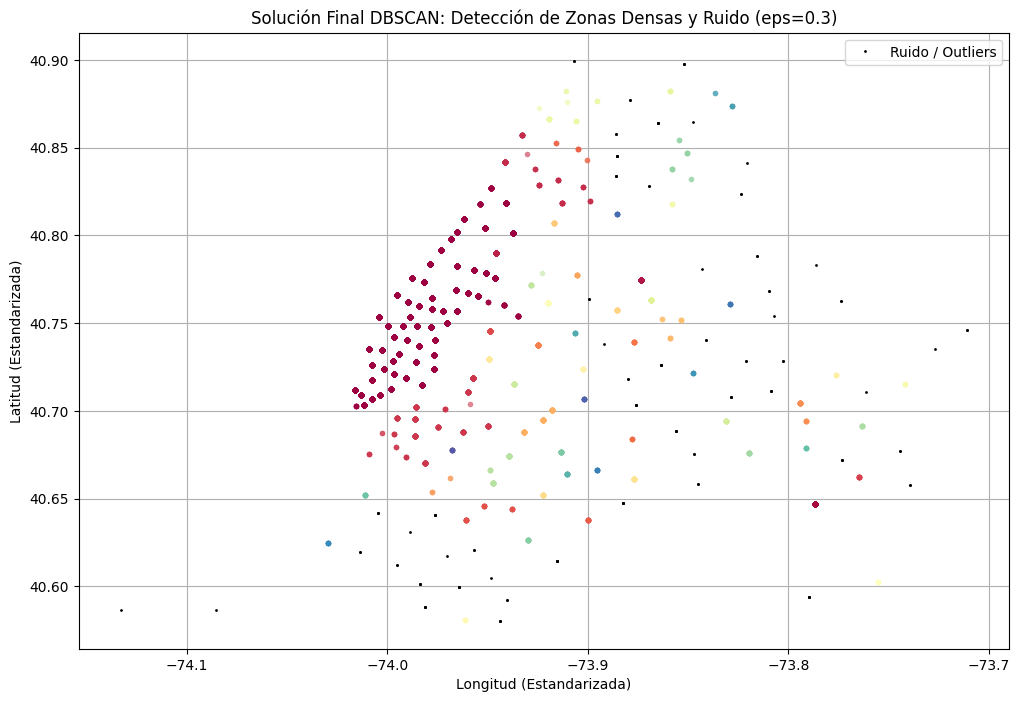

Visualización interactiva guardada como 'mapa_solucion_final.html'


In [12]:


import matplotlib.pyplot as plt
import seaborn as sns
import folium
import numpy as np
from sklearn.cluster import DBSCAN

# --- 1. Generación del Resultado Óptimo (DBSCAN) ---
# Configuración validada en la metodología
db_final = DBSCAN(eps=0.3, min_samples=5)
labels = db_final.fit_predict(X_scaled)

# Añadir etiquetas al DataFrame original para mapeo
df_vis = df_filtered.copy()
df_vis['cluster'] = labels

# --- 2. Visualización Estática para el Reporte (Matplotlib) ---
plt.figure(figsize=(12, 8))

unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Estilo para RUIDO: Negro, pequeño
        col = [0, 0, 0, 1]
        label_txt = 'Ruido / Outliers'
        markersize = 2
        alpha = 1
    else:
        # Estilo para CLÚSTERES: Color espectral, más grande
        label_txt = f'Cluster {k}'
        markersize = 4
        alpha = 0.6

    class_member_mask = (labels == k)
    xy = X[class_member_mask]
    
    # Solo agregamos etiqueta al ruido para no saturar la leyenda
    lbl = label_txt if k == -1 else None
    
    plt.plot(xy[:, 1], xy[:, 0], 'o', markerfacecolor=tuple(col),
             markeredgecolor='none', markersize=markersize, alpha=alpha, label=lbl)

plt.title('Solución Final DBSCAN: Detección de Zonas Densas y Ruido (eps=0.3)')
plt.xlabel('Longitud (Estandarizada)')
plt.ylabel('Latitud (Estandarizada)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# --- 3. Visualización Interactiva (Folium - Entregable Digital) ---
# Mapa base centrado en NYC
m = folium.Map(location=[40.73, -73.98], zoom_start=12, tiles='CartoDB positron')

# Paleta de colores simple: Azul (Cluster) vs Rojo (Ruido)
# Se usa una muestra de 5000 puntos para no saturar el navegador
df_map_sample = df_vis.sample(n=5000, random_state=42)

for idx, row in df_map_sample.iterrows():
    c_id = int(row['cluster'])
    
    # Lógica de visualización
    if c_id == -1:
        color = '#FF0000' # Rojo intenso para ruido
        radius = 3
        opacity = 0.9
        popup = "RUIDO"
    else:
        color = '#3186cc' # Azul para zona densa
        radius = 2
        opacity = 0.4
        popup = "Zona Densa"

    folium.CircleMarker(
        location=[row['PU_Latitude'], row['PU_Longitude']],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=opacity,
        popup=popup,
        weight=0
    ).add_to(m)

# Guardar resultado
m.save("mapa_solucion_final.html")
print("Visualización interactiva guardada como 'mapa_solucion_final.html'")

## Conclusiones

La implementación de DBSCAN sobre los registros de taxis de Nueva York demostró ser superior a los métodos de partición tradicionales como K-Means para el análisis de movilidad urbana. A diferencia de K-Means, que forzó divisiones geométricas artificiales ignorando barreras físicas como el río Hudson, DBSCAN se adaptó exitosamente a la topología alargada de Manhattan, identificando zonas de alta demanda continua sin necesidad de predefinir el número de clústeres. Además, el algoritmo mostró una alta eficacia en la limpieza de datos, aislando el 0.6% de los registros como ruido (viajes esporádicos o errores de GPS) mediante el parámetro min_samples, lo cual es crítico para obtener modelos libres de sesgos en entornos no supervisados.

El análisis de sensibilidad de hiperparámetros reveló que la estandarización de variables es un factor clave cuando se utiliza la distancia Euclidiana en coordenadas geográficas, evitando la deformación elíptica de los clústeres. La configuración óptima de eps=0.3 permitió distinguir la estructura de conectividad vial sin fusionar distritos distantes, revelando que la demanda de transporte no es uniforme, sino que conforma un único macro-núcleo de alta densidad en el centro de la ciudad. Estos hallazgos validan el uso de agrupamiento basado en densidad como la estrategia estándar para inferir patrones espaciales en infraestructuras urbanas complejas e irregulares.